#### 데이터전처리_로지스틱분류실험 251029

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns 
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("./credit_risk_dataset.csv") 
df.head() 

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [3]:
df.shape

(32581, 12)

#### 상관관계 시각화

In [4]:
corr_x = df.select_dtypes(['float', 'int']).corr()

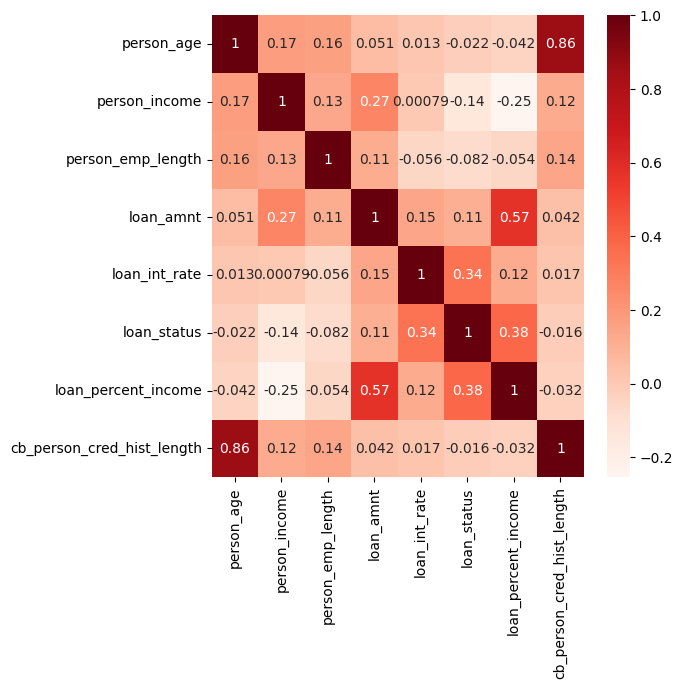

In [5]:
plt.figure(figsize=(6, 6))  
sns.heatmap(corr_x, annot=True, cmap='Reds')  
plt.show()

#### 상관계수 높은 컬럼 시각화

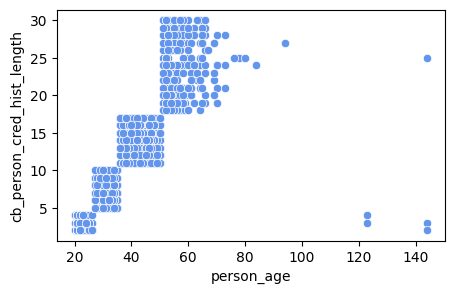

In [6]:
plt.figure(figsize=(5,3))
sns.scatterplot(data=df, x='person_age', y='cb_person_cred_hist_length', color='cornflowerblue')  
plt.show() 

In [7]:
print("미리 봐뒀던 loan_int_rate 제거할거고 (사후적인 변수라서), \n상관계수 높은 변수는 제거할지 말지 고민")

미리 봐뒀던 loan_int_rate 제거할거고 (사후적인 변수라서), 
상관계수 높은 변수는 제거할지 말지 고민


In [8]:
print("loan_int_rate랑 loan_grade(target)을 ANOVA나 Kruskal 검정 해봐야하나? ")

loan_int_rate랑 loan_grade(target)을 ANOVA나 Kruskal 검정 해봐야하나? 


In [9]:
df = df.drop(['loan_int_rate'], axis=1) 
df.head() 

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,1,0.55,Y,4


#### 결측치 확인 및 채워넣기 

In [10]:
df.isnull().sum()

person_age                      0
person_income                   0
person_home_ownership           0
person_emp_length             895
loan_intent                     0
loan_grade                      0
loan_amnt                       0
loan_status                     0
loan_percent_income             0
cb_person_default_on_file       0
cb_person_cred_hist_length      0
dtype: int64

In [11]:
df = df.fillna(0)
df.isnull().sum()

person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64

In [12]:
df.select_dtypes('object').head()

,person_home_ownership,loan_intent,loan_grade,cb_person_default_on_file
0,RENT,PERSONAL,D,Y
1,OWN,EDUCATION,B,N
2,MORTGAGE,MEDICAL,C,N
3,RENT,MEDICAL,C,N
4,RENT,MEDICAL,C,Y


#### 데이터 나누기 

In [13]:
df.columns

Index(['person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_status', 'loan_percent_income', 'cb_person_default_on_file',
       'cb_person_cred_hist_length'],
      dtype='object')

In [32]:
features = list(df.columns)
features.remove('loan_grade')

X = df[features]
y = df['loan_grade']

#### 명목형변수 변경   
- 우선은 one-hot-encoding으로 / label encoding도 고려해보기 

In [33]:
X.select_dtypes('object').head()

,person_home_ownership,loan_intent,cb_person_default_on_file
0,RENT,PERSONAL,Y
1,OWN,EDUCATION,N
2,MORTGAGE,MEDICAL,N
3,RENT,MEDICAL,N
4,RENT,MEDICAL,Y


In [15]:
# one-hot encoding
# X = pd.get_dummies(X, dtype=float)
# X.shape

(32581, 19)

In [36]:
# label encoding
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
X['person_home_ownership'] = encoder.fit_transform(X['person_home_ownership'])


array([3, 2, 0, ..., 3, 0, 3])

In [16]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 19 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      32581 non-null  int64  
 1   person_income                   32581 non-null  int64  
 2   person_emp_length               32581 non-null  float64
 3   loan_amnt                       32581 non-null  int64  
 4   loan_status                     32581 non-null  int64  
 5   loan_percent_income             32581 non-null  float64
 6   cb_person_cred_hist_length      32581 non-null  int64  
 7   person_home_ownership_MORTGAGE  32581 non-null  float64
 8   person_home_ownership_OTHER     32581 non-null  float64
 9   person_home_ownership_OWN       32581 non-null  float64
 10  person_home_ownership_RENT      32581 non-null  float64
 11  loan_intent_DEBTCONSOLIDATION   32581 non-null  float64
 12  loan_intent_EDUCATION           

In [17]:
# 트레이닝/테스트 데이터 분할 
from sklearn.model_selection import train_test_split
X_tn, X_te, y_tn, y_te = train_test_split(X, y, random_state=0, stratify=y)

In [18]:
# 데이터 표준화
from sklearn.preprocessing import StandardScaler 
std_scale = StandardScaler()
std_scale.fit(X_tn)
X_tn_std = std_scale.transform(X_tn)
X_te_std = std_scale.transform(X_te)

#### 로지스틱 모델 돌려보기 

In [19]:
# 로지스틱 회귀분석 (L2 제약식 적용)
from sklearn.linear_model import LogisticRegression
clf_logi_l2 = LogisticRegression(penalty='l2')
clf_logi_l2.fit(X_tn_std, y_tn)

LogisticRegression()

In [20]:
# 로지스틱 회귀분석 모형 (L2 제약식 적용) 추정 계수
print(clf_logi_l2.coef_)
print(clf_logi_l2.intercept_)

[[ 3.48494514e-02  1.86118111e-01  6.30031113e-02 -7.37454511e-01
  -1.03602323e+00  4.78124018e-01 -9.33230167e-02  8.41116582e-02
   7.03128955e-03 -1.19009631e-01 -1.94280768e-02  9.19569545e-02
  -1.56738804e-02 -2.32905439e-02  6.38372847e-02 -1.45444022e-02
  -1.03407937e-01  1.38890733e+00 -1.38890733e+00]
 [ 2.96233965e-02  1.43857278e-01  1.31327643e-02 -3.70759105e-01
  -8.52384514e-01  3.82521256e-01 -7.34503665e-02 -4.76510952e-02
   1.16788135e-02 -1.22739588e-01  1.11752081e-01  6.12472462e-02
  -2.51155390e-02 -1.69455374e-02  7.03874083e-02  8.82189987e-04
  -9.12490439e-02  1.38167201e+00 -1.38167201e+00]
 [ 2.05930702e-02  1.72899246e-01 -3.46187434e-02 -4.83010331e-01
  -7.11246061e-01  3.59824763e-01 -1.21436578e-02 -6.46942604e-02
   1.67958701e-03 -1.16658037e-01  1.26332977e-01  8.89990491e-02
   1.00708380e-03 -1.26432353e-02  6.92830039e-02 -2.85044198e-02
  -1.18612700e-01 -5.62357390e-01  5.62357390e-01]
 [ 2.33963131e-02 -9.95242470e-02  4.52964728e-02  6.56

In [21]:
# 예측
pred_logistic = clf_logi_l2.predict(X_te_std)
print(pred_logistic)

['B' 'A' 'A' ... 'D' 'B' 'A']


In [22]:
# confusion matrix 확인
from sklearn.metrics import confusion_matrix
conf_matrix = confusion_matrix(y_te, pred_logistic)
print(conf_matrix)

[[1781  883    0   30    0    0    0]
 [1239 1320    0   54    0    0    0]
 [ 362  420  684  149    0    0    0]
 [ 118  273  213  303    0    0    0]
 [  26   79   49   87    0    0    0]
 [   3   26    9   22    0    0    0]
 [   1    1    0   14    0    0    0]]


In [23]:
# 분류 레포트 확인
from sklearn.metrics import classification_report
class_report = classification_report(y_te, pred_logistic)
print(class_report)

              precision    recall  f1-score   support

           A       0.50      0.66      0.57      2694
           B       0.44      0.51      0.47      2613
           C       0.72      0.42      0.53      1615
           D       0.46      0.33      0.39       907
           E       0.00      0.00      0.00       241
           F       0.00      0.00      0.00        60
           G       0.00      0.00      0.00        16

    accuracy                           0.50      8146
   macro avg       0.30      0.27      0.28      8146
weighted avg       0.50      0.50      0.49      8146



In [29]:
print("loan_int_rate변수 제거하니까 성능 엄청낮음.\n그리고 클래스별로 비율이 달라서인지 undersampling이 필요할 것 같음.")
print("클래스가 다양하니까 데이터도 더 많이 필요할것같고, one-hot encoding보다는 labelencoder가 필요할 것 같음.")

loan_int_rate변수 제거하니까 성능 엄청낮음.
그리고 클래스별로 비율이 달라서인지 undersampling이 필요할 것 같음.
클래스가 다양하니까 데이터도 더 많이 필요할것같고, one-hot encoding보다는 labelencoder가 필요할 것 같음.
